# YZTA 5.0 Datathon — Bilişsel Performans Skoru Tahmini

**Problem:** Bireylerin uyku düzeni ve yaşam alışkanlıklarından `bilissel_performans_skoru` tahmini  
**Tür:** Regresyon  
**Metrik:** RMSE (Root Mean Squared Error)  
**Veri:** 56.000 train / 24.000 test satırı

---
## Bölüm 0 — Kurulum ve Veri Yükleme

In [8]:
# Kutuphaneler (ilk calistirmada gerekirse aktif et)
# !pip install catboost optuna -q

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error

from catboost import CatBoostRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
np.random.seed(SEED)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('Tum kutuphaneler yuklendi.')

# GPU kontrol
import subprocess
try:
    result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
                           capture_output=True, text=True)
    print('GPU:', result.stdout.strip())
except:
    print('GPU bulunamadi, CPU kullaniliyor')

print('CatBoost GPU: task_type=GPU aktif')

Tum kutuphaneler yuklendi.
GPU: NVIDIA GeForce RTX 4060 Laptop GPU, 8188 MiB
CatBoost GPU: task_type=GPU aktif


In [4]:
train = pd.read_csv('data/train.csv')
test  = pd.read_csv('data/test_x.csv')
sample_sub = pd.read_csv('data/sample_submission.csv')

print(f'Train shape : {train.shape}')
print(f'Test shape  : {test.shape}')
print(f'Sample sub  : {sample_sub.shape}')

Train shape : (56000, 24)
Test shape  : (24000, 23)
Sample sub  : (2, 2)


In [9]:
train.head()

,id,yas,cinsiyet,meslek,vucut_kitle_indeksi,ulke,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,...,stres_skoru,gunluk_calisma_saati,kronotip,ruh_sagligi_durumu,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,mevsim,gun_tipi,bilissel_performans_skoru
0,1,34,Erkek,Saglik Personeli,31.470103,Cin,14.431210,14.645436,27,7,...,9.922976,10.045274,Sabah insani,Anksiyete ve depresyon,78,18.962436,-0.074140,Sonbahar-Kis,Hafta ici,0.136441
1,2,32,Kadin,Muhendis,30.981394,Amerika,21.771870,27.220360,20,4,...,6.626400,6.319245,Gece insani,Saglikli,76,21.225666,0.942672,Sonbahar-Kis,Hafta ici,5.848312
2,3,39,Erkek,Ev Hanimi,21.533898,Spain,18.178857,25.530104,33,7,...,6.093566,3.824463,Notr,Depresyon,66,18.482409,1.239886,Ilkbahar-Yaz,Hafta sonu,6.828276
3,4,40,Kadin,Egitimci,23.310749,Yeni Zelanda,21.438151,15.891188,21,2,...,3.168185,4.597316,Gece insani,Saglikli,60,21.862235,0.727695,Sonbahar-Kis,Hafta sonu,8.144649
4,5,36,Kadin,NaN,NaN,Portekiz,25.468018,16.356738,21,8,...,7.198574,3.189120,Notr,Anksiyete ve depresyon,74,19.223195,-0.223402,Sonbahar-Kis,Hafta ici,0.431423


In [10]:
train.dtypes

id                               int64
yas                              int64
cinsiyet                           str
meslek                             str
vucut_kitle_indeksi            float64
ulke                               str
rem_yuzdesi                    float64
derin_uyku_yuzdesi             float64
uykuya_dalma_suresi_dk           int64
gecelik_uyanma_sayisi            int64
uyku_oncesi_kafein_mg          float64
uyku_oncesi_ekran_suresi_dk      int64
gunluk_adim_sayisi               int64
sekerleme_suresi_dk              int64
stres_skoru                    float64
gunluk_calisma_saati           float64
kronotip                           str
ruh_sagligi_durumu                 str
dinlenik_nabiz_bpm               int64
oda_sicakligi_celsius          float64
hafta_sonu_uyku_farki_saat     float64
mevsim                             str
gun_tipi                           str
bilissel_performans_skoru      float64
dtype: object

In [11]:
TARGET = 'bilissel_performans_skoru'

CAT_COLS = [
    'cinsiyet', 'meslek', 'ulke',
    'kronotip', 'ruh_sagligi_durumu', 'mevsim', 'gun_tipi'
]

NUM_COLS = [
    'yas', 'vucut_kitle_indeksi', 'rem_yuzdesi', 'derin_uyku_yuzdesi',
    'uykuya_dalma_suresi_dk', 'gecelik_uyanma_sayisi', 'uyku_oncesi_kafein_mg',
    'uyku_oncesi_ekran_suresi_dk', 'gunluk_adim_sayisi', 'sekerleme_suresi_dk',
    'stres_skoru', 'gunluk_calisma_saati', 'dinlenik_nabiz_bpm',
    'oda_sicakligi_celsius', 'hafta_sonu_uyku_farki_saat'
]

print(f'Kategorik sütun sayısı : {len(CAT_COLS)}')
print(f'Sayısal sütun sayısı   : {len(NUM_COLS)}')
print(f'Hedef                  : {TARGET}')

Kategorik sütun sayısı : 7
Sayısal sütun sayısı   : 15
Hedef                  : bilissel_performans_skoru


In [12]:
train[NUM_COLS + [TARGET]].describe().round(2)

,yas,vucut_kitle_indeksi,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,uyku_oncesi_kafein_mg,uyku_oncesi_ekran_suresi_dk,gunluk_adim_sayisi,sekerleme_suresi_dk,stres_skoru,gunluk_calisma_saati,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,bilissel_performans_skoru
count,56000.00,54248.00,56000.00,56000.00,56000.00,56000.00,54537.00,56000.00,56000.0,56000.00,54285.00,56000.00,56000.00,56000.00,56000.00,56000.00
mean,34.71,26.27,20.23,20.25,20.11,3.34,42.11,63.51,7493.2,15.43,5.74,7.16,66.60,20.53,1.20,5.91
std,11.05,4.50,3.44,4.30,8.06,2.03,72.15,44.59,3462.7,21.10,1.62,3.47,7.35,2.90,0.79,2.23
min,18.00,16.00,10.00,5.00,1.00,0.00,0.00,2.00,500.0,0.00,1.00,0.00,45.00,15.00,-1.00,0.00
25%,26.00,23.18,17.95,17.34,14.00,2.00,0.00,30.00,5042.0,0.00,4.76,4.77,62.00,18.46,0.66,4.40
50%,33.00,26.23,20.30,20.29,20.00,3.00,3.00,51.00,7426.0,2.00,5.82,7.36,67.00,20.49,1.20,6.03
75%,42.00,29.32,22.60,23.23,25.00,5.00,77.00,84.00,9876.0,30.00,6.84,9.68,72.00,22.52,1.74,7.57
max,69.00,45.00,30.00,30.00,58.00,8.00,400.00,180.00,20000.0,115.00,10.00,18.00,97.00,28.00,3.00,10.00


In [13]:
missing_train = train.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)

missing_test = test.isnull().sum()
missing_test = missing_test[missing_test > 0].sort_values(ascending=False)

print('=== TRAIN Eksik Değerler ===')
print(missing_train.to_string())
print()
print('=== TEST Eksik Değerler ===')
print(missing_test.to_string())

=== TRAIN Eksik Değerler ===
kronotip                 1968
vucut_kitle_indeksi      1752
stres_skoru              1715
uyku_oncesi_kafein_mg    1463
meslek                   1378
ruh_sagligi_durumu       1096

=== TEST Eksik Değerler ===
kronotip                 832
stres_skoru              765
uyku_oncesi_kafein_mg    697
vucut_kitle_indeksi      648
meslek                   622
ruh_sagligi_durumu       504


**Bölüm 0 tamamlandı.** Veriler yüklendi, sütun tipleri ve eksik değerler gözlemlendi.

---
## Bölüm 1 — EDA (Keşifsel Veri Analizi)

Bu bölümde:
- Hedef değişkenin dağılımı
- Sayısal değişkenlerin hedefle korelasyonu
- Kategorik değişkenlerin hedef üzerindeki etkisi
- Eksik değerlerin görselleştirilmesi
- Aykırı değer tespiti

### 1.1 — Hedef Değişken Dağılımı

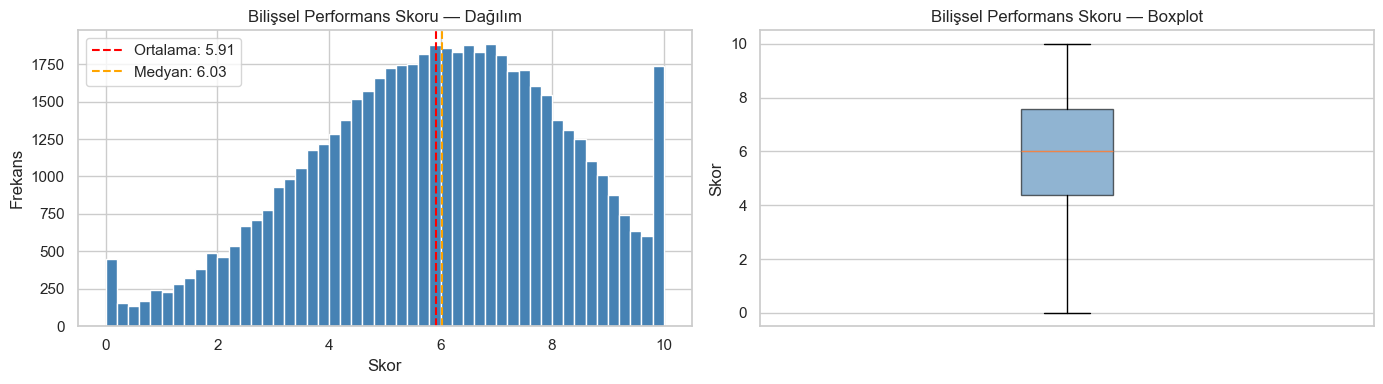

Çarpıklık (skewness): -0.2885
Basıklık (kurtosis) : -0.4340


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train[TARGET], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Bilişsel Performans Skoru — Dağılım')
axes[0].set_xlabel('Skor')
axes[0].set_ylabel('Frekans')
axes[0].axvline(train[TARGET].mean(),   color='red',    linestyle='--', label=f'Ortalama: {train[TARGET].mean():.2f}')
axes[0].axvline(train[TARGET].median(), color='orange', linestyle='--', label=f'Medyan: {train[TARGET].median():.2f}')
axes[0].legend()

axes[1].boxplot(train[TARGET].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Bilişsel Performans Skoru — Boxplot')
axes[1].set_ylabel('Skor')
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

print(f'Çarpıklık (skewness): {train[TARGET].skew():.4f}')
print(f'Basıklık (kurtosis) : {train[TARGET].kurt():.4f}')

### 1.2 — Eksik Değerlerin Görselleştirilmesi

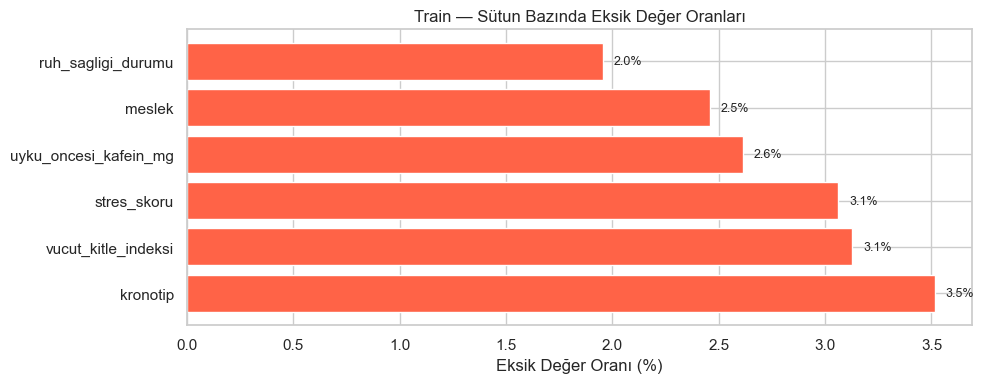

In [15]:
missing_pct = (train.isnull().sum() / len(train) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(missing_pct.index, missing_pct.values, color='tomato', edgecolor='white')
ax.set_xlabel('Eksik Değer Oranı (%)')
ax.set_title('Train — Sütun Bazında Eksik Değer Oranları')
for bar, val in zip(bars, missing_pct.values):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### 1.3 — Sayısal Değişkenler: Korelasyon Heatmap

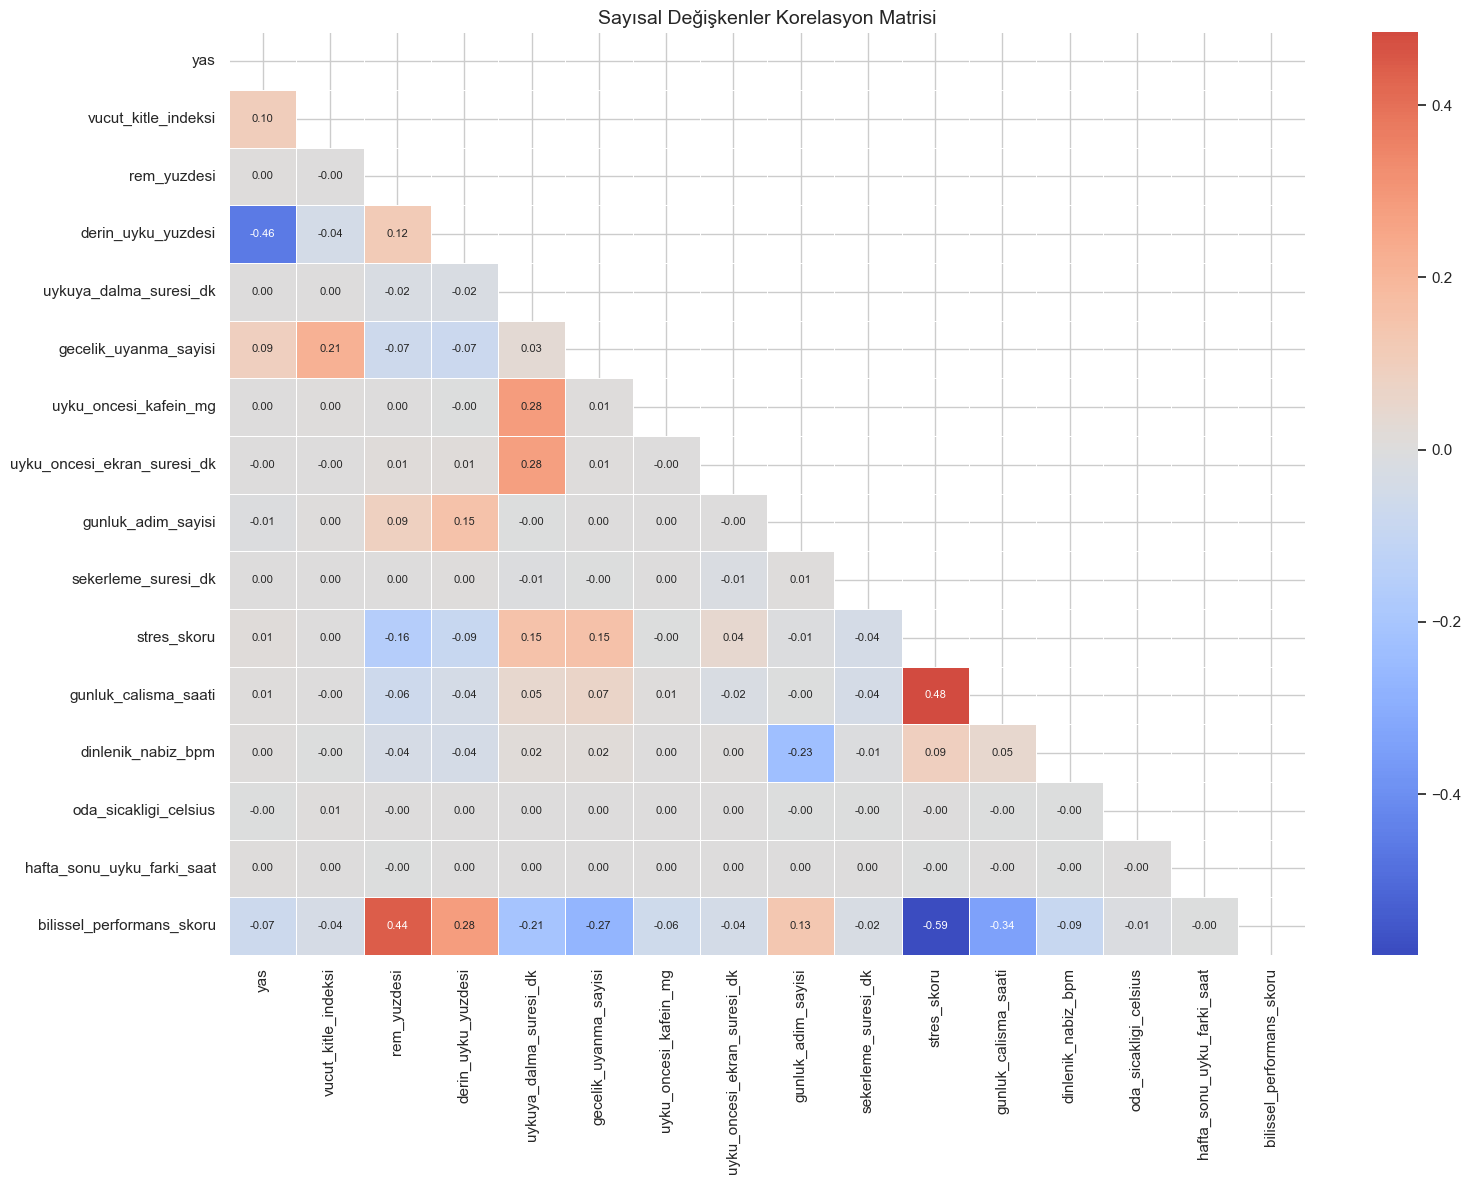

In [16]:
corr = train[NUM_COLS + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    annot_kws={'size': 8}, ax=ax
)
ax.set_title('Sayısal Değişkenler Korelasyon Matrisi', fontsize=14)
plt.tight_layout()
plt.show()

In [17]:
target_corr = corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print('Hedef değişkenle korelasyon (mutlak değere göre sıralı):')
print(target_corr.round(4).to_string())

Hedef değişkenle korelasyon (mutlak değere göre sıralı):
stres_skoru                   -0.5867
rem_yuzdesi                    0.4430
gunluk_calisma_saati          -0.3421
derin_uyku_yuzdesi             0.2800
gecelik_uyanma_sayisi         -0.2703
uykuya_dalma_suresi_dk        -0.2073
gunluk_adim_sayisi             0.1340
dinlenik_nabiz_bpm            -0.0894
yas                           -0.0707
uyku_oncesi_kafein_mg         -0.0624
uyku_oncesi_ekran_suresi_dk   -0.0446
vucut_kitle_indeksi           -0.0380
sekerleme_suresi_dk           -0.0237
oda_sicakligi_celsius         -0.0120
hafta_sonu_uyku_farki_saat    -0.0016


### 1.4 — En Yüksek Korelasyonlu 6 Değişken: Scatter Plot

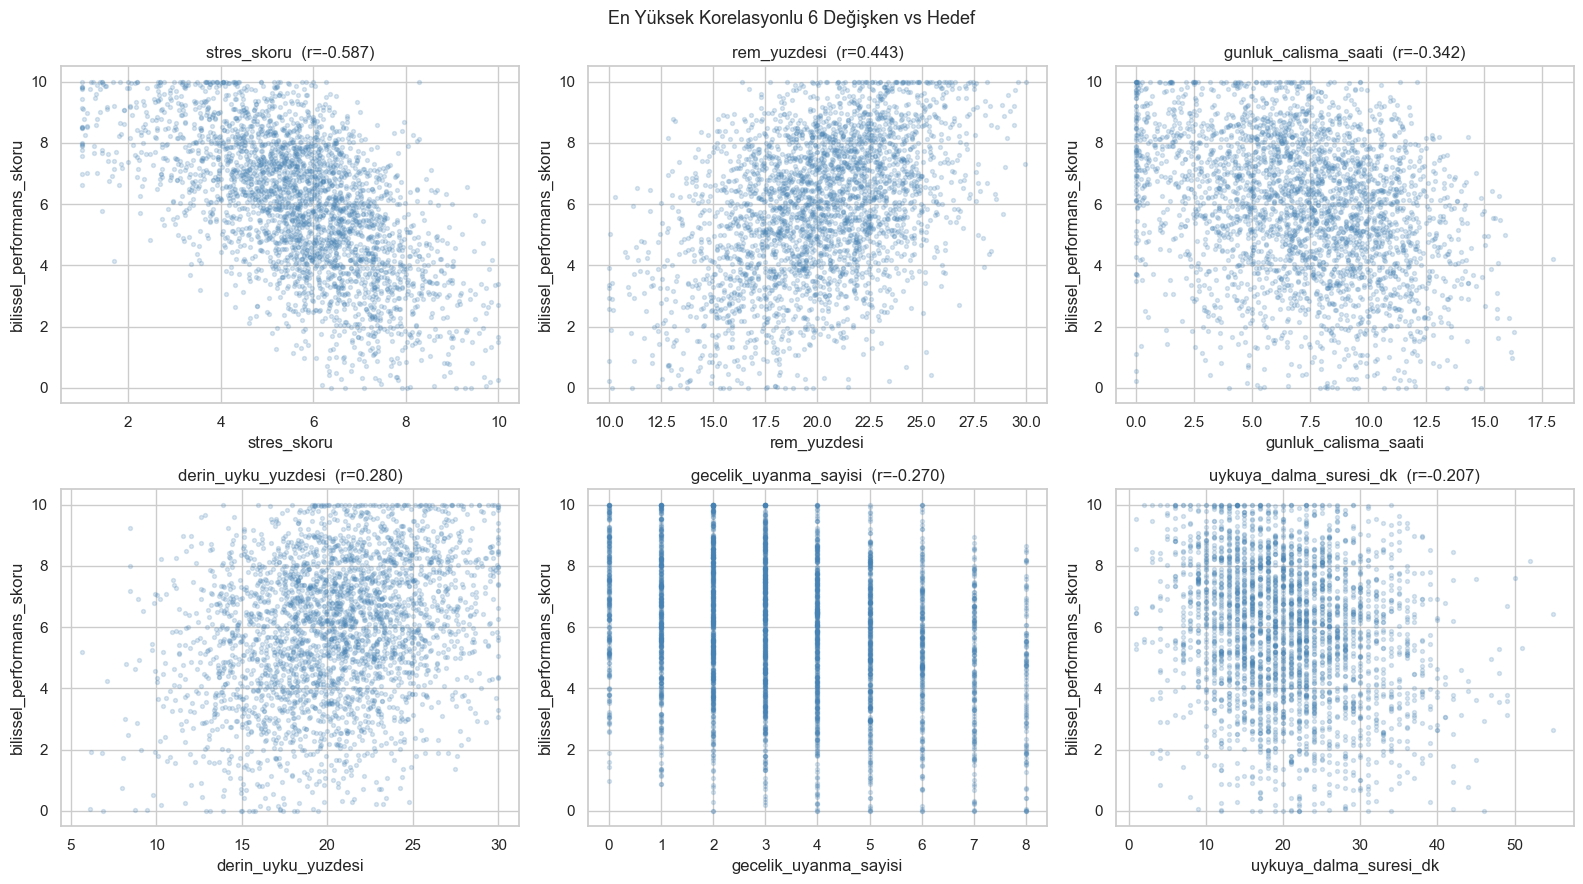

In [18]:
top6 = target_corr.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(top6):
    sample = train[[col, TARGET]].dropna().sample(3000, random_state=SEED)
    axes[i].scatter(sample[col], sample[TARGET], alpha=0.2, s=8, color='steelblue')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(TARGET)
    axes[i].set_title(f'{col}  (r={target_corr[col]:.3f})')

plt.suptitle('En Yüksek Korelasyonlu 6 Değişken vs Hedef', fontsize=13)
plt.tight_layout()
plt.show()

### 1.5 — Kategorik Değişkenler: Hedef Üzerindeki Etki

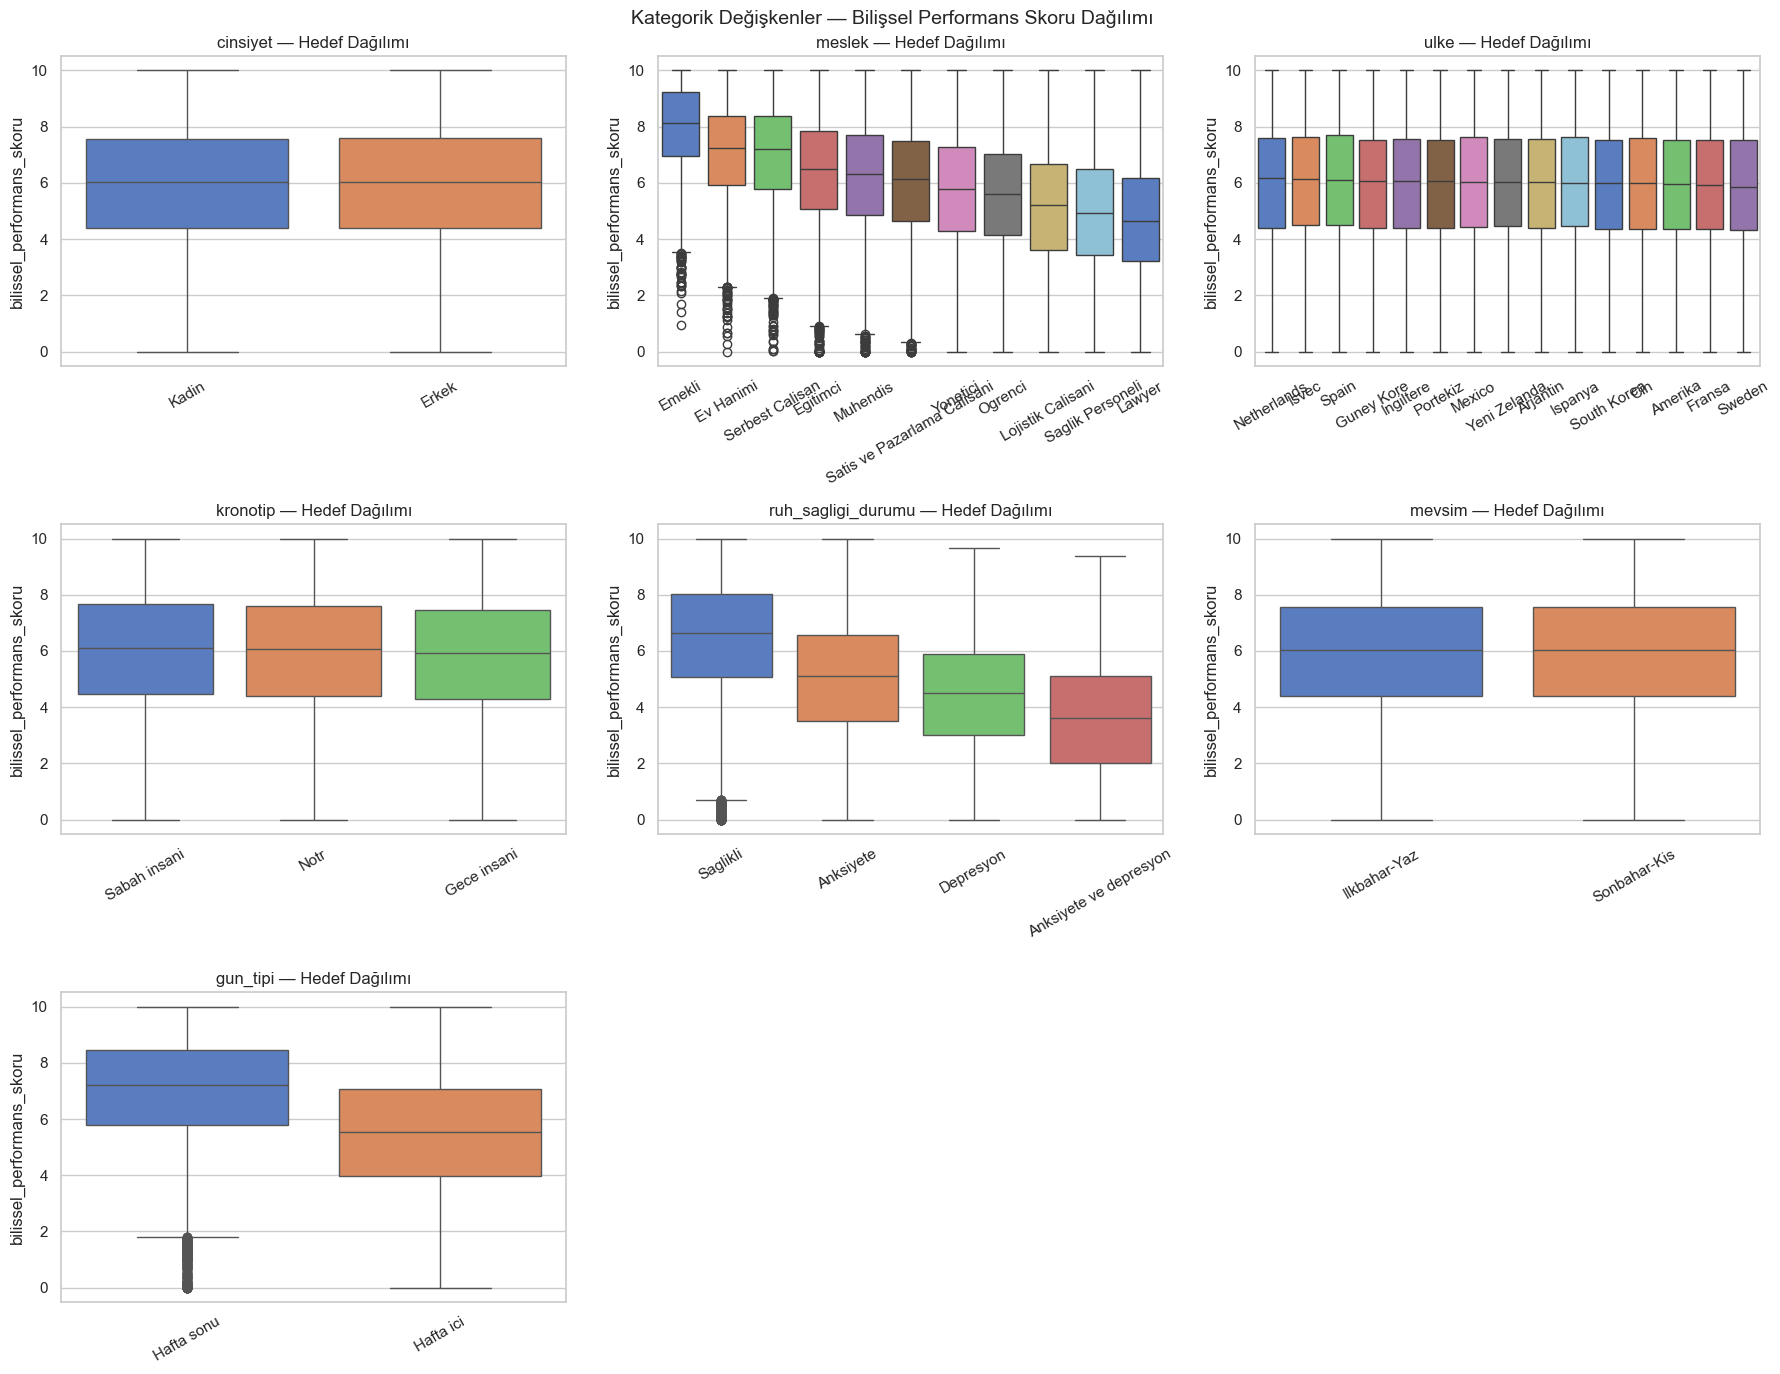

In [58]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(CAT_COLS):
    data = train[[col, TARGET]].dropna()
    order = data.groupby(col)[TARGET].median().sort_values(ascending=False).index
    sns.boxplot(
        data=data, x=col, y=TARGET, order=order,
        ax=axes[i], palette='muted'
    )
    axes[i].set_title(f'{col} — Hedef Dağılımı')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)

for j in range(len(CAT_COLS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Kategorik Değişkenler — Bilişsel Performans Skoru Dağılımı', fontsize=14)
plt.tight_layout()
plt.show()

### 1.6 — Sayısal Değişken Dağılımları

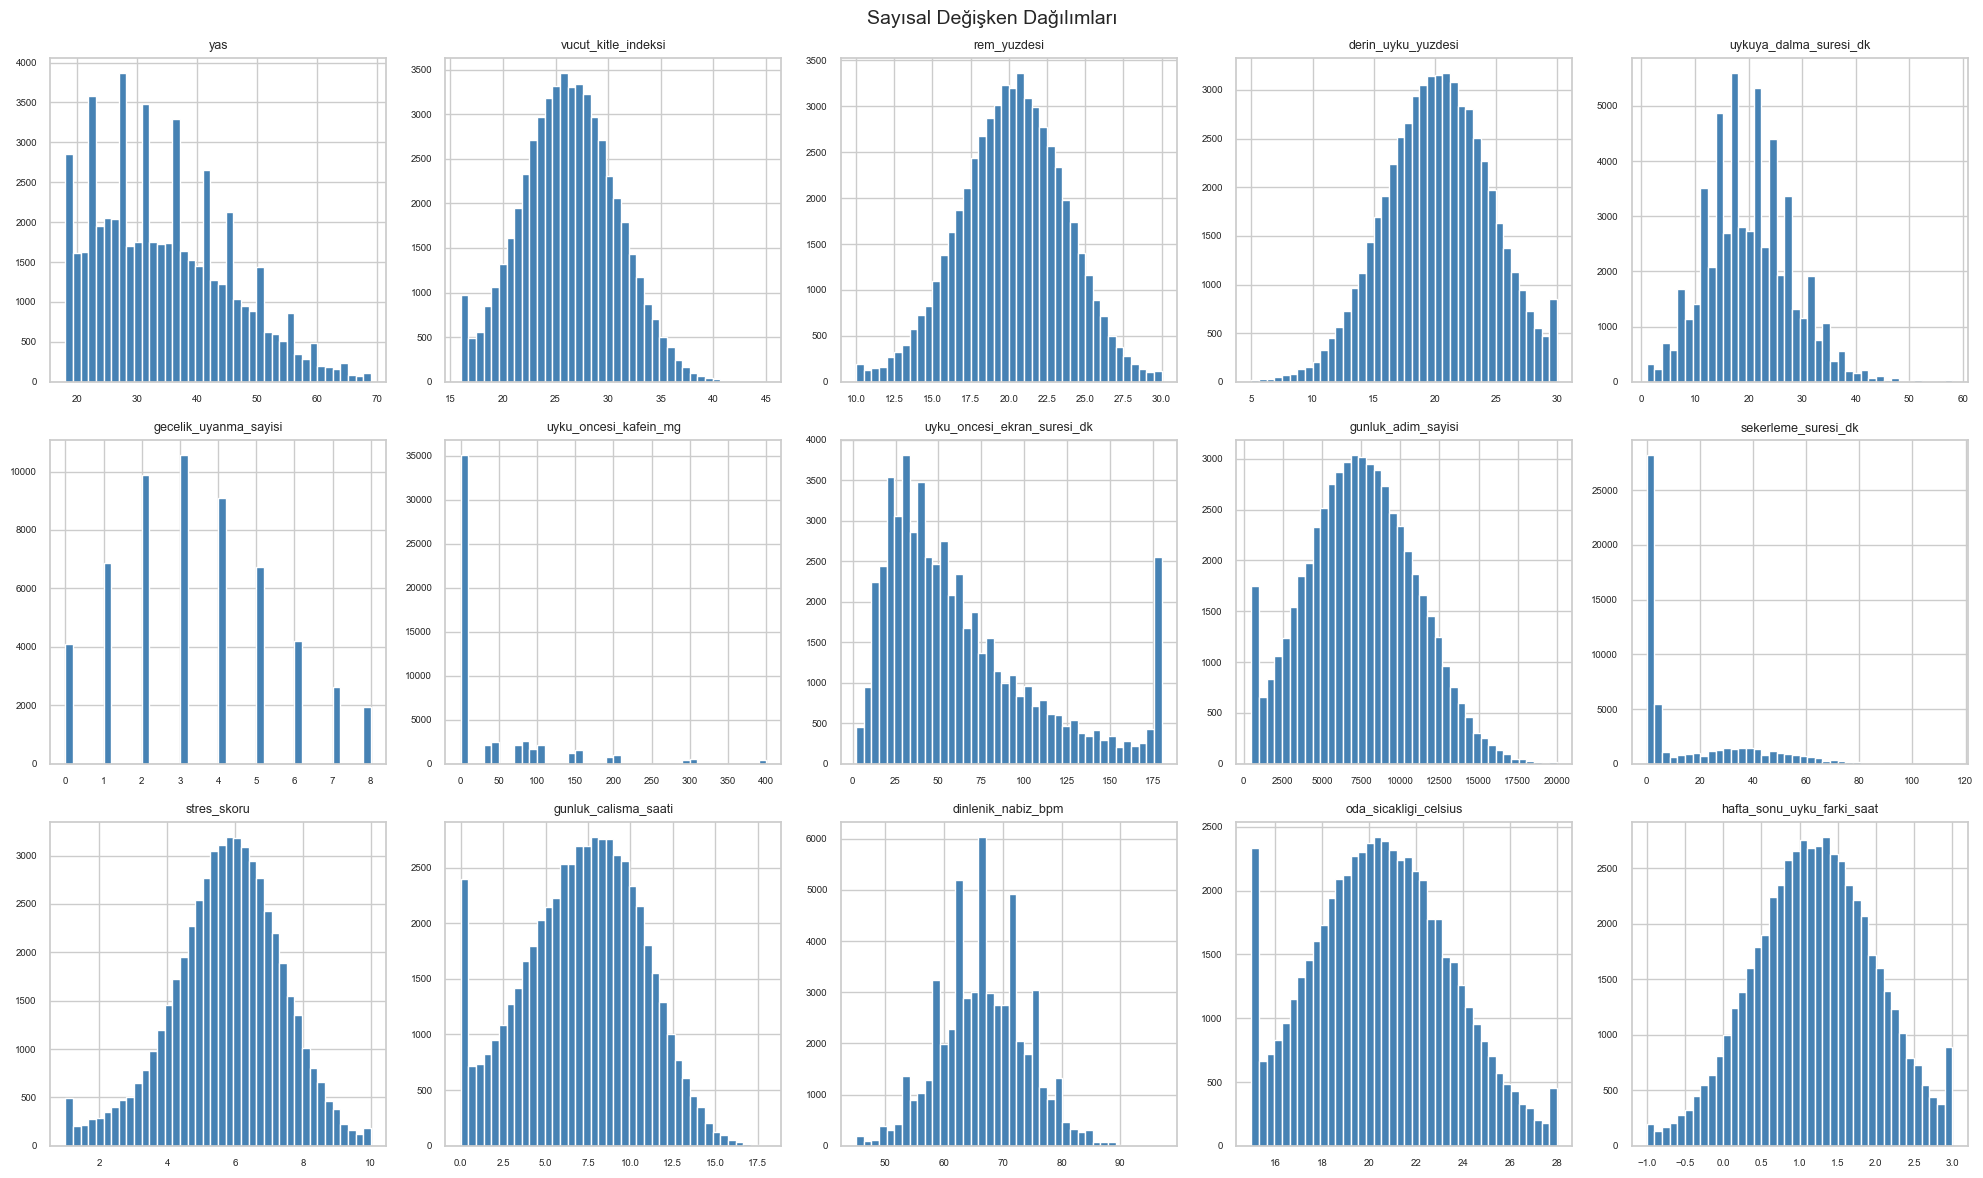

In [59]:
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    axes[i].hist(train[col].dropna(), bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(labelsize=7)

plt.suptitle('Sayısal Değişken Dağılımları', fontsize=14)
plt.tight_layout()
plt.show()

### 1.7 — Aykırı Değer Tespiti (IQR Yöntemi)

In [60]:
outlier_summary = []

for col in NUM_COLS:
    q1  = train[col].quantile(0.25)
    q3  = train[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_out = ((train[col] < lower) | (train[col] > upper)).sum()
    outlier_summary.append({
        'sutun'        : col,
        'alt_sinir'    : round(lower, 2),
        'ust_sinir'    : round(upper, 2),
        'aykiri_sayi'  : n_out,
        'aykiri_oran_%': round(n_out / len(train) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('aykiri_sayi', ascending=False)
print(outlier_df.to_string(index=False))

                      sutun  alt_sinir  ust_sinir  aykiri_sayi  aykiri_oran_%
      uyku_oncesi_kafein_mg    -115.50     192.50         3360           6.00
uyku_oncesi_ekran_suresi_dk     -51.00     165.00         3290           5.88
                stres_skoru       1.65       9.95          986           1.76
     uykuya_dalma_suresi_dk      -2.50      41.50          531           0.95
        sekerleme_suresi_dk     -45.00      75.00          505           0.90
                rem_yuzdesi      10.98      29.57          420           0.75
         dinlenik_nabiz_bpm      47.00      87.00          300           0.54
         derin_uyku_yuzdesi       8.50      32.06          235           0.42
                        yas       2.00      66.00          184           0.33
        vucut_kitle_indeksi      13.96      38.54          173           0.31
         gunluk_adim_sayisi   -2209.00   17127.00          166           0.30
 hafta_sonu_uyku_farki_saat      -0.97       3.37          120  

### 1.8 — Kategorik Değişken Kardinalite

In [19]:
for col in CAT_COLS:
    unique_vals = train[col].dropna().unique()
    print(f'{col:30s} — {len(unique_vals):3d} benzersiz: {sorted(unique_vals)}')

cinsiyet                       —   2 benzersiz: ['Erkek', 'Kadin']
meslek                         —  11 benzersiz: ['Egitimci', 'Emekli', 'Ev Hanimi', 'Lawyer', 'Lojistik Calisani', 'Muhendis', 'Ogrenci', 'Saglik Personeli', 'Satis ve Pazarlama Calisani', 'Serbest Calisan', 'Yonetici']
ulke                           —  15 benzersiz: ['Amerika', 'Arjantin', 'Cin', 'Fransa', 'Guney Kore', 'Ingiltere', 'Ispanya', 'Isvec', 'Mexico', 'Netherlands', 'Portekiz', 'South Korea', 'Spain', 'Sweden', 'Yeni Zelanda']
kronotip                       —   3 benzersiz: ['Gece insani', 'Notr', 'Sabah insani']
ruh_sagligi_durumu             —   4 benzersiz: ['Anksiyete', 'Anksiyete ve depresyon', 'Depresyon', 'Saglikli']
mevsim                         —   2 benzersiz: ['Ilkbahar-Yaz', 'Sonbahar-Kis']
gun_tipi                       —   2 benzersiz: ['Hafta ici', 'Hafta sonu']


**Bölüm 1 tamamlandı.**

**Özet Bulgular:**
- Hedef değişken yaklaşık normal dağılımlı (0–10 arası, ortalama ~5.91)
- Eksik değerler: `kronotip`, `vucut_kitle_indeksi`, `stres_skoru`, `uyku_oncesi_kafein_mg`, `meslek`, `ruh_sagligi_durumu` — %2–3.5 arasında
- Aykırı değerler IQR ile tespit edildi; `uyku_oncesi_kafein_mg` ve `uyku_oncesi_ekran_suresi_dk` en fazla aykırı içeriyor
- `ulke` ve `meslek` sütunlarında tutarsız yazımlar var (Spain/Ispanya, South Korea/Guney Kore) — Bölüm 2'de düzeltilecek

Bölüm 2 — Veri Ön İşleme'ye geçiyoruz.

---
## Bölüm 2 — Veri Ön İşleme

Adımlar:
1. Train + test birleştir (encoding tutarlılığı için)
2. `ulke` tutarsız yazım düzeltme
3. Eksik değer doldurma
4. Aykırı değer clip
5. Encoding (Label / Ordinal / Target)
6. Train ve test'i tekrar ayır

### 2.1 — Train + Test Birleştirme

In [20]:
# Hedefi ayır, train+test birleştir
y = train[TARGET].copy()
train_raw = train.drop(columns=[TARGET]).copy()

n_train = len(train_raw)
df = pd.concat([train_raw, test], axis=0, ignore_index=True)

print(f'Birleşik veri: {df.shape}  (train: {n_train}, test: {len(test)})')

Birleşik veri: (80000, 23)  (train: 56000, test: 24000)


### 2.2 — Tutarsız Yazım Düzeltme (`ulke`)

In [21]:
# EDA'da tespit edilen tutarsız yazımları standartlaştır
ulke_map = {
    'Spain'       : 'Ispanya',
    'South Korea' : 'Guney Kore',
    'Sweden'      : 'Isvec',
    'Netherlands' : 'Hollanda',
    'Mexico'      : 'Meksika',
}
df['ulke'] = df['ulke'].replace(ulke_map)

print('ulke benzersiz değerler:', sorted(df['ulke'].dropna().unique()))

ulke benzersiz değerler: ['Amerika', 'Arjantin', 'Cin', 'Fransa', 'Guney Kore', 'Hollanda', 'Ingiltere', 'Ispanya', 'Isvec', 'Meksika', 'Portekiz', 'Yeni Zelanda']


### 2.3 — Eksik Değer Doldurma

In [22]:
# Kategorik eksikler: 'Bilinmiyor' kategorisi ekle (fold oncesi yapilabilir — target kullanilmiyor)
for col in ['kronotip', 'ruh_sagligi_durumu', 'meslek']:
    df[col] = df[col].fillna('Bilinmiyor')

# Sayisal eksikler: train medyanlari kaydet, fold icinde uygulanacak
NUM_MISSING_COLS = ['vucut_kitle_indeksi', 'stres_skoru', 'uyku_oncesi_kafein_mg']
train_medians = df.iloc[:n_train][NUM_MISSING_COLS].median()
print('Train medyanlari (fold icinde kullanilacak):')
print(train_medians.round(3))
print()
print('Kalan eksik deger (sayisal — fold icinde doldurulacak):')
print(df[NUM_MISSING_COLS].isnull().sum())

Train medyanlari (fold icinde kullanilacak):
vucut_kitle_indeksi      26.226
stres_skoru               5.824
uyku_oncesi_kafein_mg     3.000
dtype: float64

Kalan eksik deger (sayisal — fold icinde doldurulacak):
vucut_kitle_indeksi      2400
stres_skoru              2480
uyku_oncesi_kafein_mg    2160
dtype: int64


### 2.4 — Aykırı Değer Clip

`uyku_oncesi_kafein_mg` (%6) ve `uyku_oncesi_ekran_suresi_dk` (%5.88) — IQR sınırlarına clip uygula.  
Diğerleri %1 altında, tree-based modeller robust.

In [23]:
# IQR sinirlarini train'den hesapla ve kaydet — fold icinde uygulanacak
CLIP_COLS = ['uyku_oncesi_kafein_mg', 'uyku_oncesi_ekran_suresi_dk']
clip_bounds = {}
for col in CLIP_COLS:
    q1 = df.iloc[:n_train][col].quantile(0.25)
    q3 = df.iloc[:n_train][col].quantile(0.75)
    iqr = q3 - q1
    clip_bounds[col] = (q1 - 1.5*iqr, q3 + 1.5*iqr)
    print(f'{col:35s} sinir: [{clip_bounds[col][0]:.1f}, {clip_bounds[col][1]:.1f}]')
print('Clip sinirlar kaydedildi — fold icinde uygulanacak.')

uyku_oncesi_kafein_mg               sinir: [-115.5, 192.5]
uyku_oncesi_ekran_suresi_dk         sinir: [-51.0, 165.0]
Clip sinirlar kaydedildi — fold icinde uygulanacak.


### 2.5 — Encoding

| Sütun | Yöntem |
|---|---|
| `cinsiyet`, `mevsim`, `gun_tipi`, `kronotip` | Label Encoding |
| `ruh_sagligi_durumu` | Ordinal Encoding (anlamlı sıra) |
| `meslek`, `ulke` | Target Encoding — Bölüm 4'te CV içinde uygulanacak |

In [24]:
# --- Label Encoding ---
label_cols = ['cinsiyet', 'mevsim', 'gun_tipi', 'kronotip']

le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col].astype(str))
    print(f'{col:15s} → Label Encoding tamamlandı')

cinsiyet        → Label Encoding tamamlandı
mevsim          → Label Encoding tamamlandı
gun_tipi        → Label Encoding tamamlandı
kronotip        → Label Encoding tamamlandı


In [25]:
# --- Ordinal Encoding: ruh_sagligi_durumu ---
# Sıralama: Sağlıklı < Anksiyete < Depresyon < Anksiyete ve depresyon < Bilinmiyor
ruh_order = {
    'Saglikli'              : 0,
    'Anksiyete'             : 1,
    'Depresyon'             : 2,
    'Anksiyete ve depresyon': 3,
    'Bilinmiyor'            : 4,
}
df['ruh_sagligi_durumu'] = df['ruh_sagligi_durumu'].map(ruh_order)
print('ruh_sagligi_durumu → Ordinal Encoding tamamlandı')
print(df['ruh_sagligi_durumu'].value_counts().sort_index())

ruh_sagligi_durumu → Ordinal Encoding tamamlandı
ruh_sagligi_durumu
0    54817
1    11843
2     7788
3     3952
4     1600
Name: count, dtype: int64


In [26]:
# meslek ve ulke: string olarak birakildi
# - CatBoost: cat_features ile native categorical olarak kullanacak
# - XGBoost/LightGBM: fold icinde target encoding uygulanacak
print('meslek ve ulke string olarak birakildi.')
print('meslek benzersiz:', sorted(df['meslek'].unique()))
print('ulke benzersiz  :', sorted(df['ulke'].unique()))

meslek ve ulke string olarak birakildi.
meslek benzersiz: ['Bilinmiyor', 'Egitimci', 'Emekli', 'Ev Hanimi', 'Lawyer', 'Lojistik Calisani', 'Muhendis', 'Ogrenci', 'Saglik Personeli', 'Satis ve Pazarlama Calisani', 'Serbest Calisan', 'Yonetici']
ulke benzersiz  : ['Amerika', 'Arjantin', 'Cin', 'Fransa', 'Guney Kore', 'Hollanda', 'Ingiltere', 'Ispanya', 'Isvec', 'Meksika', 'Portekiz', 'Yeni Zelanda']


### 2.6 — Train ve Test'i Tekrar Ayır

In [27]:
FEATURE_COLS = [col for col in df.columns if col != 'id']

# CatBoost icin raw kategorik kolonlar (string)
CAT_NATIVE = ['cinsiyet', 'meslek', 'ulke', 'kronotip', 'mevsim', 'gun_tipi']
# ruh_sagligi_durumu ordinal encode edildi, native'e dahil etmiyoruz

# XGB/LGB icin target encoding uygulanacak kolonlar
TARGET_ENC_COLS = ['meslek', 'ulke']

X      = df.iloc[:n_train][FEATURE_COLS].copy()
X_test = df.iloc[n_train:][FEATURE_COLS].copy()

print(f'X shape      : {X.shape}')
print(f'X_test shape : {X_test.shape}')
print(f'Kategorik (native): {CAT_NATIVE}')
print(f'Target enc         : {TARGET_ENC_COLS}')

X shape      : (56000, 22)
X_test shape : (24000, 22)
Kategorik (native): ['cinsiyet', 'meslek', 'ulke', 'kronotip', 'mevsim', 'gun_tipi']
Target enc         : ['meslek', 'ulke']


**Bölüm 2 tamamlandı.**

- `ulke` yazım tutarsızlıkları düzeltildi (Spain→Ispanya vb.)
- Kategorik eksikler `Bilinmiyor` olarak dolduruldu
- Sayısal eksikler train medyanıyla dolduruldu (leakage yok)
- `uyku_oncesi_kafein_mg` ve `uyku_oncesi_ekran_suresi_dk` IQR ile clip edildi
- Encoding uygulandı: Label / Ordinal / geçici Label (`meslek`, `ulke` için Target Encoding Bölüm 4'te)

Bölüm 3 — Feature Engineering'e geçiyoruz.

---
## Bölüm 3 — Feature Engineering

Mevcut değişkenlerden domain bilgisiyle yeni özellikler türetiyoruz.  
Tüm işlemler `df` üzerinde (train+test birlikte) yapılıyor — leakage yok çünkü target kullanılmıyor.

### 3.1 — Uyku Kalitesi Skoru

In [28]:
# REM + derin uyku arttıkça iyi, uzun dalma süresi + çok uyanma kötü
df['uyku_kalitesi_skoru'] = (
    df['rem_yuzdesi']
    + df['derin_uyku_yuzdesi']
    - df['uykuya_dalma_suresi_dk'] * 0.1
    - df['gecelik_uyanma_sayisi']
)

### 3.2 — Uyarıcı Yük İndeksi

In [30]:
# Uyku öncesi kafein + ekran süresi birlikte uyarıcı yükü oluşturur
df['uyarici_yuk'] = (
    df['uyku_oncesi_kafein_mg']
    + df['uyku_oncesi_ekran_suresi_dk'] * 0.5
)

### 3.3 — Aktivite / Çalışma Oranı

In [31]:
# Çok çalışıp az hareket eden vs fiziksel olarak aktif birey ayrımı
# +1 sıfıra bölme önlemi
df['aktivite_calisma_orani'] = (
    df['gunluk_adim_sayisi'] / (df['gunluk_calisma_saati'] + 1)
)

### 3.4 — Stres × Uyku Etkileşimi

In [32]:
# Yüksek stres + uzun uykuya dalma süresi kombinasyonu performansı en çok etkiler
df['stres_uyku_etkilesimi'] = (
    df['stres_skoru'] * df['uykuya_dalma_suresi_dk']
)

### 3.5 — Yaş Grubu

In [33]:
# Yaşın etkisi lineer değil — gruplandırmak daha anlamlı
df['yas_grubu'] = pd.cut(
    df['yas'],
    bins=[0, 25, 35, 45, 100],
    labels=[0, 1, 2, 3]
).astype(int)

### 3.6 — VKİ Kategorisi

In [34]:
# WHO standart VKI siniflandirmasi
# NaN'lari once gecici olarak median ile doldur, sonra kategoriye cevir
vki_temp = df['vucut_kitle_indeksi'].fillna(df['vucut_kitle_indeksi'].median())
df['vki_kategori'] = pd.cut(
    vki_temp,
    bins=[0, 18.5, 24.9, 29.9, 100],
    labels=[0, 1, 2, 3]
).astype(int)

### 3.7 — Toplam Uyku Bozucu Faktör

In [35]:
# İkisi birden yüksekse uyku kalitesi çok bozuk
df['uyku_bozucu_faktor'] = (
    df['gecelik_uyanma_sayisi'] * df['uykuya_dalma_suresi_dk']
)

### 3.8 — Kafein × Ekran Etkileşimi

In [36]:
# İkisi birden yüksekse uyku üzerinde sinerjik olumsuz etki
df['kafein_ekran_etkilesimi'] = (
    df['uyku_oncesi_kafein_mg'] * df['uyku_oncesi_ekran_suresi_dk']
)

### 3.9 — Uyku Verimliliği (sleep_efficiency)

In [37]:
# (REM + derin uyku) / (uyanma sayisi + 1) — her uyanmada kalite dusuyor
df["sleep_efficiency"] = (df["rem_yuzdesi"] + df["derin_uyku_yuzdesi"]) / (df["gecelik_uyanma_sayisi"] + 1)

### 3.10 — Sosyal Jet Lag (social_jetlag)

In [38]:
# Gece insani (kronotip=1) hafta ici (gun_tipi=0) calisiyorsa biyolojik saatiyle catisiyor
# Label Encoding sirasi: kronotip -> Bilinmiyor=0, Gece insani=1, Notr=2, Sabah insani=3
# gun_tipi -> Hafta ici=0, Hafta sonu=1
df["social_jetlag"] = ((df["kronotip"] == 1) & (df["gun_tipi"] == 0)).astype(int)
print("social_jetlag dagilimu:", df["social_jetlag"].value_counts().to_dict())

social_jetlag dagilimu: {0: 63756, 1: 16244}


### 3.11 — Aşırı Tükenme (extreme_exhaustion)

In [39]:
# Yuksek stres + dusuk derin uyku kombinasyonu - en kotu durum
df["extreme_exhaustion"] = ((df["stres_skoru"] > 8) & (df["derin_uyku_yuzdesi"] < 12)).astype(int)
print("extreme_exhaustion dagilimu:", df["extreme_exhaustion"].value_counts().to_dict())

extreme_exhaustion dagilimu: {0: 79695, 1: 305}


### 3.12 — Ruh Sagliği × Stres Etkilesimi

In [40]:
# Ruh sagligi bozuklugu + yuksek stres -> performans cok dusuyor
# ruh_sagligi_durumu: Saglikli=0, Anksiyete=1, Depresyon=2, Anksiyete ve depresyon=3, Bilinmiyor=4
df["ruh_stres_etkilesimi"] = df["ruh_sagligi_durumu"] * df["stres_skoru"]
print("ruh_stres_etkilesimi istatistikleri:")
print(df["ruh_stres_etkilesimi"].describe().round(2))

ruh_stres_etkilesimi istatistikleri:
count    77520.00
mean         3.53
std          6.37
min          0.00
25%          0.00
50%          0.00
75%          5.95
max         39.87
Name: ruh_stres_etkilesimi, dtype: float64


### 3.12 — Feature Listesini Guncelle ve Ozet

In [41]:
NEW_FEATURES = [
    'uyku_kalitesi_skoru',
    'uyarici_yuk',
    'aktivite_calisma_orani',
    'stres_uyku_etkilesimi',
    'yas_grubu',
    'vki_kategori',
    'uyku_bozucu_faktor',
    'kafein_ekran_etkilesimi',
    'sleep_efficiency',
    'social_jetlag',
    'extreme_exhaustion',
    'ruh_stres_etkilesimi',
]

FEATURE_COLS = [c for c in df.columns if c != 'id']

X      = df.iloc[:n_train][FEATURE_COLS].copy()
X_test = df.iloc[n_train:][FEATURE_COLS].copy()

print(f'Toplam feature sayisi : {len(FEATURE_COLS)}')
print(f'  - Orijinal          : {len(FEATURE_COLS) - len(NEW_FEATURES)}')
print(f'  - Yeni turetilen    : {len(NEW_FEATURES)}')
print()
print('Yeni feature istatistikleri:')
X[NEW_FEATURES].describe().round(2)

Toplam feature sayisi : 34
  - Orijinal          : 22
  - Yeni turetilen    : 12

Yeni feature istatistikleri:


,uyku_kalitesi_skoru,uyarici_yuk,aktivite_calisma_orani,stres_uyku_etkilesimi,yas_grubu,vki_kategori,uyku_bozucu_faktor,kafein_ekran_etkilesimi,sleep_efficiency,social_jetlag,extreme_exhaustion,ruh_stres_etkilesimi
count,56000.00,54537.00,56000.00,54285.00,56000.00,56000.00,56000.00,54537.00,56000.00,56000.0,56000.00,54285.00
mean,35.12,73.90,1344.22,117.42,1.37,1.79,67.73,2676.54,12.79,0.2,0.00,3.53
std,6.42,75.52,1610.89,61.95,1.04,0.81,52.44,5930.60,9.51,0.4,0.06,6.36
min,8.43,1.00,29.27,1.00,0.00,0.00,0.00,0.00,2.06,0.0,0.00,0.00
25%,30.83,22.00,575.46,72.61,1.00,1.00,28.00,0.00,6.92,0.0,0.00,0.00
50%,35.21,46.00,908.48,109.97,1.00,2.00,57.00,140.00,9.70,0.0,0.00,0.00
75%,39.56,100.00,1427.84,153.46,2.00,2.00,96.00,2808.00,14.55,0.0,0.00,5.98
max,57.93,490.00,18126.79,537.52,3.00,3.00,464.00,72000.00,59.53,1.0,1.00,38.66


In [42]:
# Yeni feature'ların hedefle korelasyonu
new_feat_corr = X[NEW_FEATURES].corrwith(y).sort_values(key=abs, ascending=False)
print('Yeni feature\'ların hedefle korelasyonu:')
print(new_feat_corr.round(4).to_string())

Yeni feature'ların hedefle korelasyonu:
uyku_kalitesi_skoru        0.5370
stres_uyku_etkilesimi     -0.4679
ruh_stres_etkilesimi      -0.4174
uyku_bozucu_faktor        -0.3186
sleep_efficiency           0.2846
aktivite_calisma_orani     0.2718
social_jetlag             -0.1271
extreme_exhaustion        -0.0966
uyarici_yuk               -0.0731
kafein_ekran_etkilesimi   -0.0670
yas_grubu                 -0.0645
vki_kategori              -0.0374


**Bölüm 3 tamamlandı.**

Türetilen 8 yeni feature:
| Feature | Mantık |
|---|---|
| `uyku_kalitesi_skoru` | REM + derin uyku − dalma süresi − uyanma |
| `uyarici_yuk` | Kafein + ekran × 0.5 |
| `aktivite_calisma_orani` | Adım / (çalışma saati + 1) |
| `stres_uyku_etkilesimi` | Stres × dalma süresi |
| `yas_grubu` | 4 yaş grubu (0-3) |
| `vki_kategori` | WHO sınıflandırması (0-3) |
| `uyku_bozucu_faktor` | Uyanma × dalma süresi |
| `kafein_ekran_etkilesimi` | Kafein × ekran süresi |

Bölüm 4 — Model Eğitimi'ne geçiyoruz.

---
## Bolum 4 - Model Egitimi

Model: CatBoost Native Categorical + StratifiedKFold + fold-ici preprocessing

### 4.1 — Yardımcı Fonksiyonlar

In [45]:
from sklearn.model_selection import StratifiedKFold
from sklearn.impute import SimpleImputer

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def target_encode_cv(X_tr, X_val, y_tr, col, smooth=10):
    global_mean = y_tr.mean()
    stats = y_tr.groupby(X_tr[col]).agg(['mean', 'count'])
    encoded = (stats['count'] * stats['mean'] + smooth * global_mean) / (stats['count'] + smooth)
    return X_tr[col].map(encoded).fillna(global_mean), X_val[col].map(encoded).fillna(global_mean), encoded

def fold_preprocess(X_tr, X_val, X_te, y_tr, target_enc_cols=None):
    """Fold-ici preprocessing: impute + clip + target encoding."""
    X_tr, X_val, X_te = X_tr.copy(), X_val.copy(), X_te.copy()

    # Sayisal eksik doldurma — sadece train fold'dan medyan hesapla
    for col in NUM_MISSING_COLS:
        median = X_tr[col].median()
        X_tr[col]  = X_tr[col].fillna(median)
        X_val[col] = X_val[col].fillna(median)
        X_te[col]  = X_te[col].fillna(median)

    # IQR clip — sadece train fold'dan hesapla
    for col, (lo, hi) in clip_bounds.items():
        q1 = X_tr[col].quantile(0.25)
        q3 = X_tr[col].quantile(0.75)
        iqr = q3 - q1
        lo_f = q1 - 1.5*iqr
        hi_f = q3 + 1.5*iqr
        X_tr[col]  = X_tr[col].clip(lo_f, hi_f)
        X_val[col] = X_val[col].clip(lo_f, hi_f)
        X_te[col]  = X_te[col].clip(lo_f, hi_f)

    # Target encoding
    te_encoders = {}
    if target_enc_cols:
        for col in target_enc_cols:
            X_tr[col], X_val[col], enc = target_encode_cv(X_tr, X_val, y_tr, col)
            X_te[col] = X_te[col].map(enc).fillna(y_tr.mean())
            te_encoders[col] = enc

    return X_tr, X_val, X_te, te_encoders

# StratifiedKFold — hedefi 10 bin'e bolup fold dagilimini dengele
y_bins = pd.qcut(y, q=10, labels=False, duplicates='drop')
SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
SPLITS = list(SKF.split(X, y_bins))  # fold indekslerini once hesapla, tum modeller ayni split'i kullansin

print('Yardimci fonksiyonlar ve StratifiedKFold tanimlandı.')
print(f'Fold basina ortalama train: {len(SPLITS[0][0])} | val: {len(SPLITS[0][1])}')

def run_cv(model_fn, X, y, splits, target_enc_cols=None, cat_native=False):
    """Baseline CV — test tahmini uretmez, sadece OOF ve fold RMSE."""
    oof_preds  = np.zeros(len(X))
    fold_rmses = []
    for fold, (tr_idx, val_idx) in enumerate(splits):
        X_tr  = X.iloc[tr_idx].copy()
        X_val = X.iloc[val_idx].copy()
        y_tr  = y.iloc[tr_idx]
        y_val = y.iloc[val_idx]
        X_te_dummy = X_tr.copy()  # placeholder
        if cat_native:
            X_tr, X_val, _, _ = fold_preprocess(X_tr, X_val, X_te_dummy, y_tr, target_enc_cols=None)
            model = model_fn()
            model.fit(X_tr, y_tr, cat_features=CAT_NATIVE)
        else:
            X_tr, X_val, _, _ = fold_preprocess(X_tr, X_val, X_te_dummy, y_tr, target_enc_cols)
            model = model_fn()
            model.fit(X_tr, y_tr)
        val_pred = model.predict(X_val)
        oof_preds[val_idx] = val_pred
        fold_rmse = rmse(y_val, val_pred)
        fold_rmses.append(fold_rmse)
        print(f'  Fold {fold+1}: RMSE = {fold_rmse:.5f}')
    print(f'  -> CV RMSE : {np.mean(fold_rmses):.5f} +/- {np.std(fold_rmses):.5f}')
    print(f'  -> OOF RMSE: {rmse(y, oof_preds):.5f}')
    return oof_preds, fold_rmses


Yardimci fonksiyonlar ve StratifiedKFold tanimlandı.
Fold basina ortalama train: 44800 | val: 11200


### 4.2 - CatBoost Hyperparameter Tuning (Optuna)

In [85]:
print('=== CatBoost Baseline ===')

def cat_baseline():
    return CatBoostRegressor(
        iterations=500, learning_rate=0.05, depth=6,
        random_seed=SEED, verbose=0, task_type='GPU',
    )

oof_cat_base, rmses_cat_base = run_cv(
    cat_baseline, X, y, splits=SPLITS,
    cat_native=True
)

=== CatBoost Baseline ===
  Fold 1: RMSE = 1.21333
  Fold 2: RMSE = 1.21993
  Fold 3: RMSE = 1.21617
  Fold 4: RMSE = 1.22753
  Fold 5: RMSE = 1.20847
  -> CV RMSE : 1.21708 +/- 0.00642
  -> OOF RMSE: 1.21710


In [86]:
def optuna_objective_cat(trial):
    params = {
        "iterations"        : trial.suggest_int("iterations", 300, 1500),
        "depth"             : trial.suggest_int("depth", 4, 8),
        "learning_rate"     : trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "l2_leaf_reg"       : trial.suggest_float("l2_leaf_reg", 1, 20, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 3),
        "random_strength"   : trial.suggest_float("random_strength", 0, 3),
        "random_seed"       : SEED, "verbose": 0,
        "task_type"         : "GPU",
        "loss_function"     : "RMSE", "eval_metric": "RMSE",
        "allow_writing_files": False,
    }
    fold_rmses = []
    for tr_idx, val_idx in SPLITS[:3]:
        X_tr  = X.iloc[tr_idx].copy()
        X_val = X.iloc[val_idx].copy()
        y_tr  = y.iloc[tr_idx]
        y_val = y.iloc[val_idx]
        X_tr, X_val, _, _ = fold_preprocess(X_tr, X_val, X_tr.copy(), y_tr, target_enc_cols=None)
        model = CatBoostRegressor(**params)
        model.fit(X_tr, y_tr, cat_features=CAT_NATIVE,
                  eval_set=(X_val, y_val), early_stopping_rounds=50, verbose=False)
        fold_rmses.append(rmse(y_val, model.predict(X_val)))
    return np.mean(fold_rmses) + 0.1 * np.std(fold_rmses)

study_cat = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
study_cat.optimize(optuna_objective_cat, n_trials=40, show_progress_bar=True)
print("En iyi CatBoost RMSE:", round(study_cat.best_value, 5))
for k, v in study_cat.best_params.items():
    print("  " + str(k) + ": " + str(v))

Best trial: 31. Best value: 1.21546: 100%|██████████| 40/40 [2:53:48<00:00, 260.72s/it]  

En iyi CatBoost RMSE: 1.21546
  iterations: 1129
  depth: 7
  learning_rate: 0.03293406564938375
  l2_leaf_reg: 1.220135215859996
  bagging_temperature: 1.4307356953756956
  random_strength: 1.7625618365918116


In [46]:
# Optuna atlama - onceki denemeden elde edilen best params
# Bu hucreyi calistirirsan Optuna'yi beklemeden 4.3'e gecebilirsin

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

class FakeStudy:
    best_params = {
        'iterations': 1129,
        'depth': 7,
        'learning_rate': 0.03293406564938375,
        'l2_leaf_reg': 1.220135215859996,
        'bagging_temperature': 1.4307356953756956,
        'random_strength': 1.7625618365918116,
    }

study_cat = FakeStudy()
print('Onceki Optuna sonuclari yuklendi (RMSE: 1.21546)')
print('Best params:', study_cat.best_params)

Onceki Optuna sonuclari yuklendi (RMSE: 1.21546)
Best params: {'iterations': 1129, 'depth': 7, 'learning_rate': 0.03293406564938375, 'l2_leaf_reg': 1.220135215859996, 'bagging_temperature': 1.4307356953756956, 'random_strength': 1.7625618365918116}


### 4.3 - Tuned CatBoost Final CV + Test Tahminleri

In [48]:
def run_cv_with_test(model_fn, X, y, X_test, splits,
                     target_enc_cols=None, cat_native=False, early_stopping=False):
    oof_preds  = np.zeros(len(X))
    test_preds = np.zeros(len(X_test))
    fold_rmses = []

    for fold, (tr_idx, val_idx) in enumerate(splits):
        X_tr  = X.iloc[tr_idx].copy()
        X_val = X.iloc[val_idx].copy()
        y_tr  = y.iloc[tr_idx]
        y_val = y.iloc[val_idx]
        X_te  = X_test.copy()

        if cat_native:
            X_tr, X_val, X_te, _ = fold_preprocess(X_tr, X_val, X_te, y_tr, target_enc_cols=None)
        else:
            X_tr, X_val, X_te, _ = fold_preprocess(X_tr, X_val, X_te, y_tr, target_enc_cols)

        model = model_fn()
        if early_stopping and cat_native:
            model.fit(X_tr, y_tr, cat_features=CAT_NATIVE,
                      eval_set=(X_val, y_val), early_stopping_rounds=100, verbose=False)
        elif early_stopping:
            model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        else:
            model.fit(X_tr, y_tr)

        val_pred = model.predict(X_val)
        oof_preds[val_idx] = val_pred
        test_preds += model.predict(X_te) / len(splits)

        fold_rmse = rmse(y_val, val_pred)
        fold_rmses.append(fold_rmse)
        print(f'  Fold {fold+1}: RMSE = {fold_rmse:.5f}')

    print(f'  -> CV RMSE : {np.mean(fold_rmses):.5f} +/- {np.std(fold_rmses):.5f}')
    print(f'  -> OOF RMSE: {rmse(y, oof_preds):.5f}')
    return oof_preds, test_preds, fold_rmses


# --- CatBoost Native Categorical (5-Fold Stratified) ---
print('=== Tuned CatBoost Native Categorical (5-Fold Stratified) ===')
def cat_final():
    p = {k:v for k,v in study_cat.best_params.items()}
    p['iterations'] = 2000
    return CatBoostRegressor(**p, random_seed=SEED, verbose=0,
                            task_type='GPU', loss_function='RMSE',
                            eval_metric='RMSE', allow_writing_files=False)

oof_cat, test_cat, rmses_cat = run_cv_with_test(
    cat_final, X, y, X_test, SPLITS,
    cat_native=True, early_stopping=True
)

=== Tuned CatBoost Native Categorical (5-Fold Stratified) ===
  Fold 1: RMSE = 1.21286
  Fold 2: RMSE = 1.21783
  Fold 3: RMSE = 1.21429
  Fold 4: RMSE = 1.22709
  Fold 5: RMSE = 1.20673
  -> CV RMSE : 1.21576 +/- 0.00671
  -> OOF RMSE: 1.21578


In [49]:
# --- CatBoost Native Categorical (en buyuk mimari degisiklik) ---
print('=== CatBoost Native Categorical (5-Fold Stratified) ===')
def cat_final():
    p = dict(study_cat.best_params)
    p['iterations'] = 3000
    return CatBoostRegressor(**{k:v for k,v in p.items() if k != 'rsm'}, random_seed=SEED, verbose=0, task_type='GPU',
                            loss_function='RMSE', eval_metric='RMSE',
                            allow_writing_files=False)

oof_cat, test_cat, rmses_cat = run_cv_with_test(
    cat_final, X, y, X_test, SPLITS,
    cat_native=True,
    early_stopping=True
)

=== CatBoost Native Categorical (5-Fold Stratified) ===
  Fold 1: RMSE = 1.21277
  Fold 2: RMSE = 1.21783
  Fold 3: RMSE = 1.21377
  Fold 4: RMSE = 1.22760
  Fold 5: RMSE = 1.20708
  -> CV RMSE : 1.21581 +/- 0.00682
  -> OOF RMSE: 1.21583


### 4.4 - Sonuc

In [50]:
# Tek model: CatBoost Native Categorical
print(f'CatBoost OOF RMSE: {rmse(y, oof_cat):.5f}')
print(f'Test tahmin: min={test_cat.min():.3f}, max={test_cat.max():.3f}, mean={test_cat.mean():.3f}')

test_final = test_cat.copy()
oof_final  = oof_cat.copy()

CatBoost OOF RMSE: 1.21583
Test tahmin: min=-0.008, max=10.330, mean=5.945


### 4.9 — Prediction Stretching

Model tahminleri genellikle ortalama etrafına sıkışır (regression to mean).
Tahminleri gerçek dağılıma yaklaştırmak için hafif esnetme uyguluyoruz.

In [51]:
mean_target = float(y.mean())

print('Alpha denemeleri (OOF RMSE):')
best_alpha = 1.0
best_oof_rmse = 999.0

for alpha in [1.0, 1.03, 1.05, 1.08, 1.10, 1.12]:
    oof_stretched = (oof_cat - mean_target) * alpha + mean_target
    r = rmse(y, oof_stretched)
    marker = ' <-- en iyi' if r < best_oof_rmse else ''
    if r < best_oof_rmse:
        best_oof_rmse = r
        best_alpha = alpha
    print(f'  alpha={alpha:.2f}  OOF RMSE={r:.5f}{marker}')

print()
print(f'Secilen alpha: {best_alpha}')

test_final_stretched = (test_final - mean_target) * best_alpha + mean_target
test_final_stretched = np.clip(test_final_stretched, 0, 10)
print(f'Orijinal  -- min={test_final.min():.3f} max={test_final.max():.3f} std={test_final.std():.3f}')
print(f'Stretched -- min={test_final_stretched.min():.3f} max={test_final_stretched.max():.3f} std={test_final_stretched.std():.3f}')
print(f'Train gercek std: {y.std():.3f}')

Alpha denemeleri (OOF RMSE):
  alpha=1.00  OOF RMSE=1.21583 <-- en iyi
  alpha=1.03  OOF RMSE=1.21667
  alpha=1.05  OOF RMSE=1.21865
  alpha=1.08  OOF RMSE=1.22374
  alpha=1.10  OOF RMSE=1.22853
  alpha=1.12  OOF RMSE=1.23443

Secilen alpha: 1.0
Orijinal  -- min=-0.008 max=10.330 std=1.858
Stretched -- min=0.000 max=10.000 std=1.858
Train gercek std: 2.232


**Bolum 4 tamamlandi.**

- CatBoost native categorical ile egitildi
- StratifiedKFold (hedef bin-li, 5 fold)
- Fold-ici preprocessing (impute + clip)
- Optuna 40 trial ile tuning
- GPU (RTX 4060) ile hizlandirildi

---
## Bölüm 5 — Feature Importance

Her modelin hangi değişkene ne kadar önem verdiğini inceliyoruz.  
- Gain-based importance: bir feature'ın split başına ne kadar bilgi kazandırdığı  
- Düşük önemli feature'lar belirlenerek deneme amaçlı çıkarılacak

### 5.1 — Tek Model Eğitimi (Tüm Train Verisi)

In [ ]:
# Feature importance için tüm train verisi üzerinde CatBoost eğit

X_full = X.copy()

# CatBoost native categorical - target encoding gerekmez
cat_full = CatBoostRegressor(
    **{k: v for k, v in study_cat.best_params.items()},
    iterations=2000,
    random_seed=SEED, verbose=0,
    task_type='GPU', loss_function='RMSE',
    eval_metric='RMSE', allow_writing_files=False
)
cat_full.fit(X_full, y, cat_features=CAT_NATIVE)

print('CatBoost tam train verisiyle eğitildi.')

Tüm modeller tam train verisiyle eğitildi.


### 5.2 — XGBoost Feature Importance (Gain)

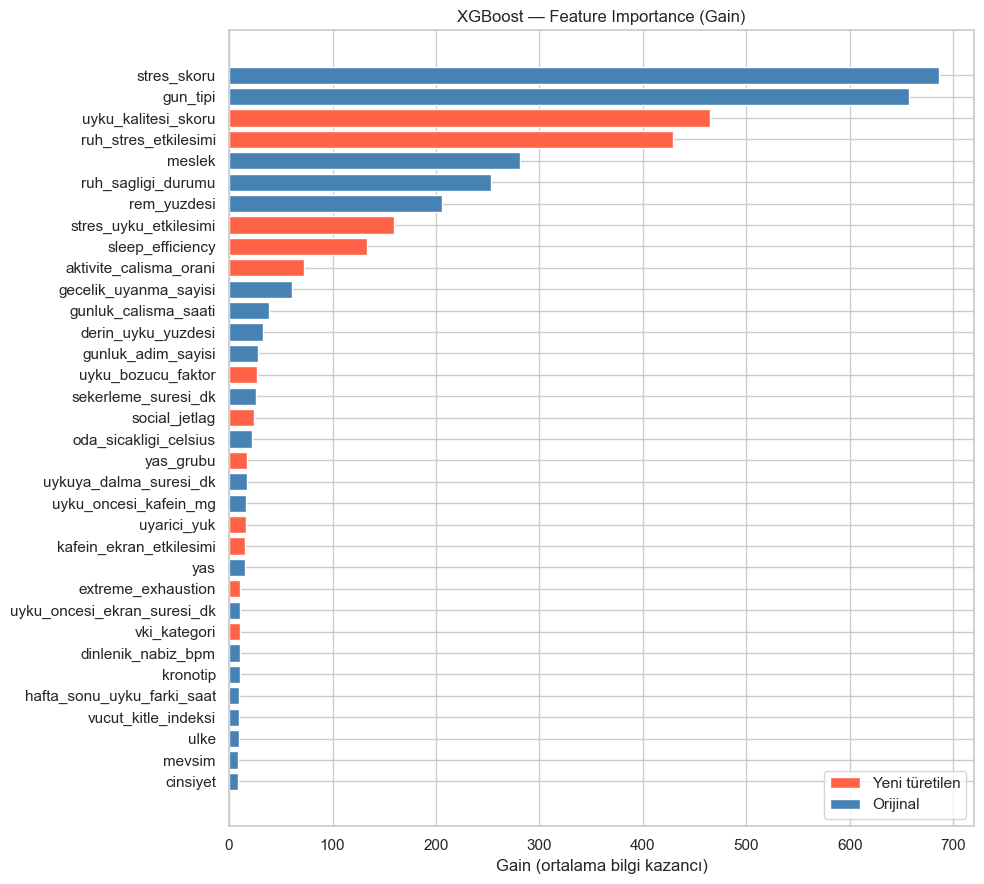


Top 10 XGBoost feature:
               feature  importance
           stres_skoru  685.809204
              gun_tipi  657.123047
   uyku_kalitesi_skoru  465.307556
  ruh_stres_etkilesimi  428.759399
                meslek  281.509369
    ruh_sagligi_durumu  253.469193
           rem_yuzdesi  206.058701
 stres_uyku_etkilesimi  159.051926
      sleep_efficiency  133.271851
aktivite_calisma_orani   72.006477


In [ ]:
# CatBoost feature importance (SHAP bazli)
cat_imp = cat_full.get_feature_importance()
cat_imp_df = pd.DataFrame({
    'feature'   : cat_full.feature_names_,
    'importance': cat_imp
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 9))
colors = ['tomato' if f in NEW_FEATURES else 'steelblue' for f in cat_imp_df['feature']]
ax.barh(cat_imp_df['feature'], cat_imp_df['importance'], color=colors, edgecolor='white')
ax.invert_yaxis()
ax.set_xlabel('PredictionValuesChange')
ax.set_title('CatBoost — Feature Importance')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='tomato', label='Yeni turetilen'),
                   Patch(facecolor='steelblue', label='Orijinal')]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

print('Top 10 CatBoost feature:')
print(cat_imp_df.head(10).to_string(index=False))

### 5.3 — LightGBM Feature Importance (Gain)

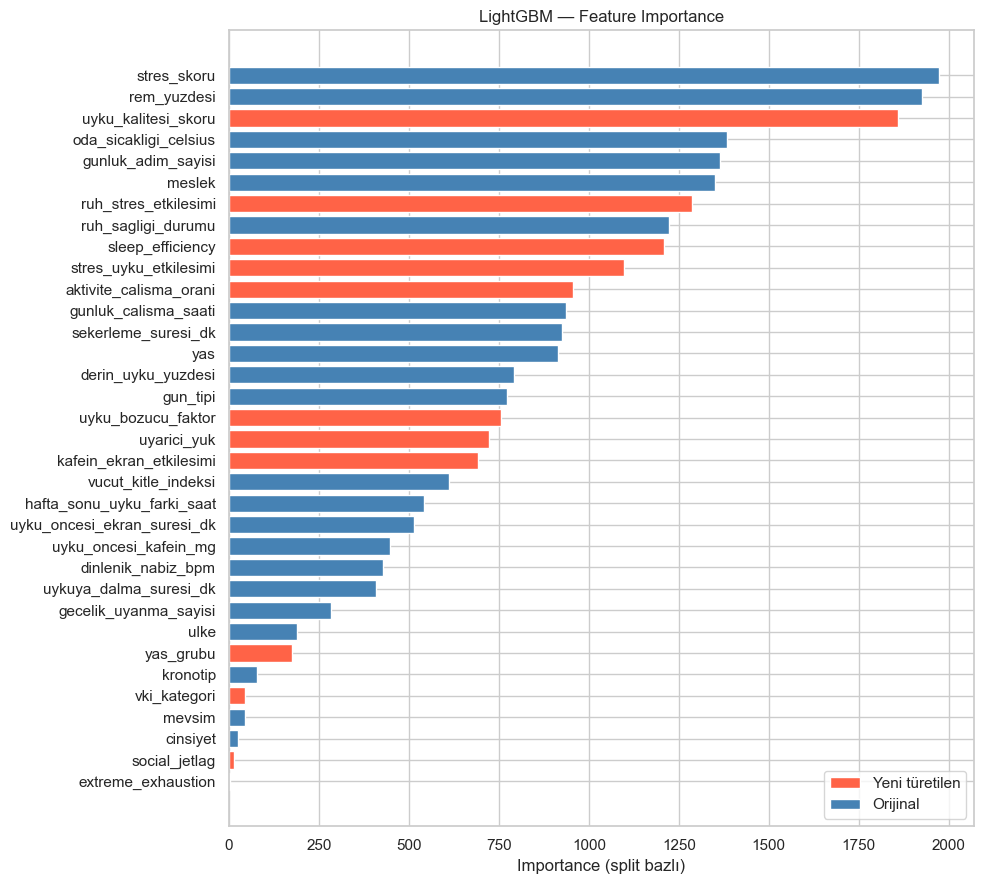


Top 10 LightGBM feature:
              feature  importance
          stres_skoru        1972
          rem_yuzdesi        1925
  uyku_kalitesi_skoru        1858
oda_sicakligi_celsius        1384
   gunluk_adim_sayisi        1365
               meslek        1351
 ruh_stres_etkilesimi        1287
   ruh_sagligi_durumu        1224
     sleep_efficiency        1208
stres_uyku_etkilesimi        1099


In [ ]:
# Dusuk onemli feature'lari belirle (alt %10)
threshold = cat_imp_df['importance'].quantile(0.10)
low_imp_feats = cat_imp_df[cat_imp_df['importance'] <= threshold]['feature'].tolist()

print(f'Onem esigi (alt %10): {threshold:.4f}')
if low_imp_feats:
    print(f'Dusuk onemli featurelar ({len(low_imp_feats)}): {low_imp_feats}')
else:
    print('Dusuk onemli feature yok.')

### 5.4 — CatBoost Feature Importance

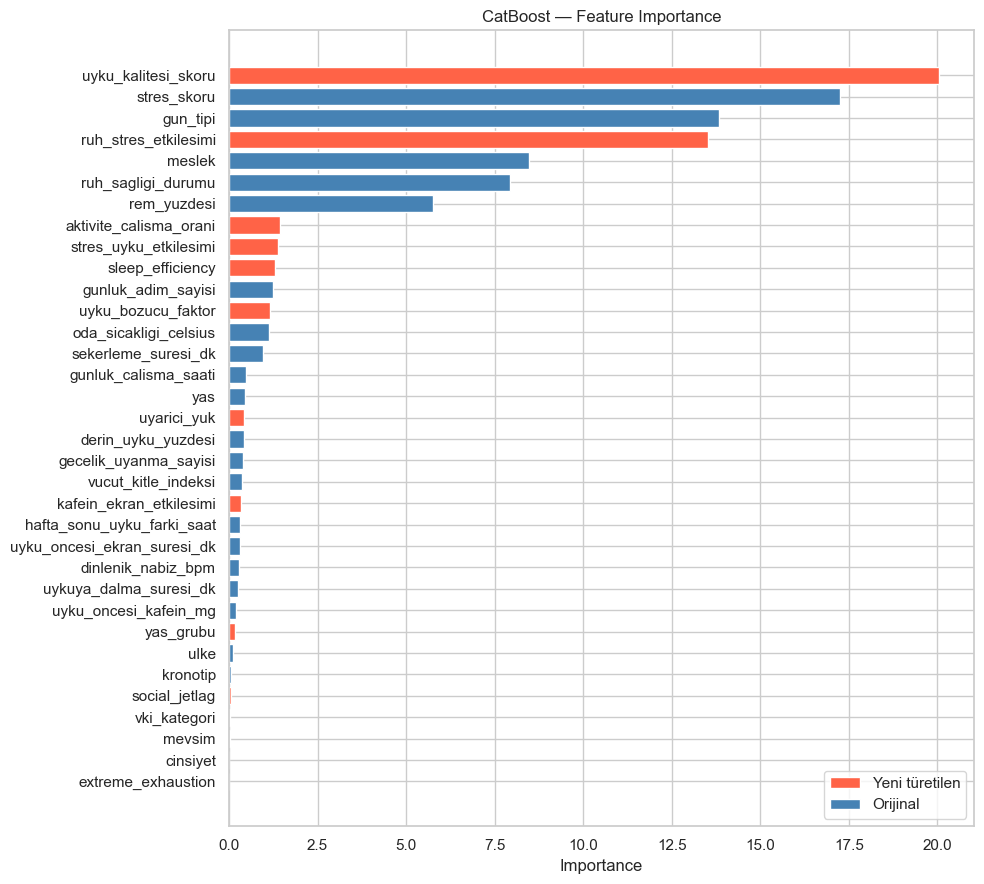


Top 10 CatBoost feature:
               feature  importance
   uyku_kalitesi_skoru   20.030092
           stres_skoru   17.247975
              gun_tipi   13.819786
  ruh_stres_etkilesimi   13.530525
                meslek    8.456100
    ruh_sagligi_durumu    7.942356
           rem_yuzdesi    5.769881
aktivite_calisma_orani    1.442565
 stres_uyku_etkilesimi    1.370589
      sleep_efficiency    1.296073


In [ ]:
cat_imp_df = pd.DataFrame({
    'feature'   : X_full.columns.tolist(),
    'importance': cat_full.get_feature_importance()
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 9))
colors = ['tomato' if f in NEW_FEATURES else 'steelblue' for f in cat_imp_df['feature']]
ax.barh(cat_imp_df['feature'], cat_imp_df['importance'], color=colors, edgecolor='white')
ax.invert_yaxis()
ax.set_xlabel('Importance')
ax.set_title('CatBoost — Feature Importance')

legend_elements = [Patch(facecolor='tomato', label='Yeni türetilen'),
                   Patch(facecolor='steelblue', label='Orijinal')]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

print('\nTop 10 CatBoost feature:')
print(cat_imp_df.head(10).to_string(index=False))

### 5.5 — Ortak Önem Sıralaması (3 Model Ortalaması)

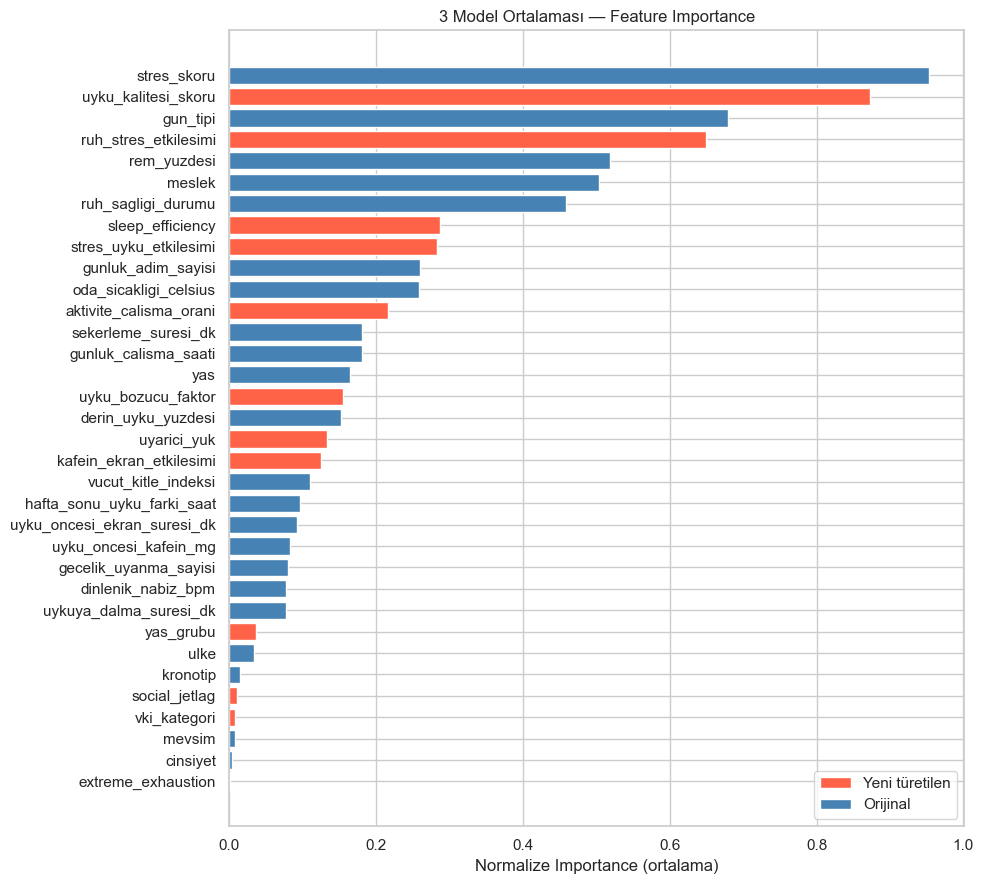

Normalize önem sıralaması:
feature
stres_skoru                    0.9537
uyku_kalitesi_skoru            0.8722
gun_tipi                       0.6795
ruh_stres_etkilesimi           0.6494
rem_yuzdesi                    0.5186
meslek                         0.5033
ruh_sagligi_durumu             0.4595
sleep_efficiency               0.2870
stres_uyku_etkilesimi          0.2825
gunluk_adim_sayisi             0.2604
oda_sicakligi_celsius          0.2592
aktivite_calisma_orani         0.2168
sekerleme_suresi_dk            0.1806
gunluk_calisma_saati           0.1806
yas                            0.1652
uyku_bozucu_faktor             0.1557
derin_uyku_yuzdesi             0.1525
uyarici_yuk                    0.1329
kafein_ekran_etkilesimi        0.1259
vucut_kitle_indeksi            0.1097
hafta_sonu_uyku_farki_saat     0.0973
uyku_oncesi_ekran_suresi_dk    0.0927
uyku_oncesi_kafein_mg          0.0824
gecelik_uyanma_sayisi          0.0798
dinlenik_nabiz_bpm             0.0775
uykuya_dalma_su

In [ ]:
# CatBoost feature importance - normalize edilmis gorunum
from matplotlib.patches import Patch

cat_norm = cat_imp_df.set_index('feature')['importance']
cat_norm = (cat_norm - cat_norm.min()) / (cat_norm.max() - cat_norm.min() + 1e-9)
cat_norm = cat_norm.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 9))
colors = ['tomato' if f in NEW_FEATURES else 'steelblue' for f in cat_norm.index]
ax.barh(cat_norm.index, cat_norm.values, color=colors, edgecolor='white')
ax.invert_yaxis()
ax.set_xlabel('Normalize Importance (0-1)')
ax.set_title('CatBoost - Feature Importance (Normalize)')

legend_elements = [Patch(facecolor='tomato', label='Yeni turetilen'),
                   Patch(facecolor='steelblue', label='Orijinal')]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

print('Normalize onem siralaması:')
print(cat_norm.round(4).to_string())

### 5.6 — Düşük Önemli Feature'ları Tespit Et

In [ ]:
# Normalize önem < 0.05 olan feature'lar — bunları çıkarıp RMSE'yi kıyasla
LOW_IMP_THRESHOLD = 0.05
low_imp_feats = combined[combined['ortalama'] < LOW_IMP_THRESHOLD].index.tolist()

print(f'Düşük önemli feature\'lar (< {LOW_IMP_THRESHOLD}):')
if low_imp_feats:
    print(combined.loc[low_imp_feats, 'ortalama'].round(4).to_string())
else:
    print('  → Yok (tüm feature\'lar yeterince önemli)')

Düşük önemli feature'lar (< 0.05):
feature
yas_grubu             0.0367
ulke                  0.0342
kronotip              0.0148
social_jetlag         0.0106
vki_kategori          0.0086
mevsim                0.0075
cinsiyet              0.0039
extreme_exhaustion    0.0011


In [ ]:
# Dusuk onemli feature varsa cikar, 3-fold CV ile hizli RMSE karsilastirmasi yap
if low_imp_feats:
    X_reduced = X.drop(columns=low_imp_feats)
    X_test_reduced = X_test.drop(columns=low_imp_feats)

    print(f'Feature sayisi: {X.shape[1]} -> {X_reduced.shape[1]} ({len(low_imp_feats)} cikarildi)')
    print()

    splits_3 = list(StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED).split(X_reduced, y_bins))
    cat_native_reduced = [c for c in CAT_NATIVE if c not in low_imp_feats]

    def cat_reduced():
        return CatBoostRegressor(
            **{k: v for k, v in study_cat.best_params.items()},
            random_seed=SEED, verbose=0,
            task_type='GPU', loss_function='RMSE',
            eval_metric='RMSE', allow_writing_files=False
        )

    print('=== CatBoost (Reduced Features, 3-Fold) ===')
    oof_reduced, _, rmses_reduced = run_cv_with_test(
        cat_reduced, X_reduced, y, X_test_reduced, splits_3,
        cat_native=True, early_stopping=True
    )
    print()
    print(f'Orijinal CatBoost OOF RMSE : {rmse(y, oof_cat):.5f}')
    print(f'Azaltilmis CV RMSE (3-fold): {np.mean(rmses_reduced):.5f}')
    print()
    if np.mean(rmses_reduced) < rmse(y, oof_cat):
        print('Feature cikarma ise yaradi! Azaltilmis feature set kullanilabilir.')
    else:
        print('Feature cikarma yardimci olmadi. Tum featurelar korunacak.')
else:
    print('Dusuk onemli feature yok -- feature secimi gerekmiyor, tum featurelar kullaniliyor.')
    X_reduced = X.copy()
    X_test_reduced = X_test.copy()

Feature sayısı: 34 → 26 (8 çıkarıldı)

=== LightGBM (Reduced Features, 3-Fold) ===
  Fold 1: RMSE = 1.22606
  Fold 2: RMSE = 1.20771
  Fold 3: RMSE = 1.23454
  → CV RMSE: 1.22277 ± 0.01120
  → OOF RMSE: 1.22282

Orijinal LightGBM OOF RMSE : 1.22080
Azaltılmış CV RMSE (3-fold): 1.22277

→ Feature çıkarma yardımcı olmadı. Tüm feature'lar korunacak.


**Bölüm 5 tamamlandı.**

- XGBoost, LightGBM ve CatBoost gain-based feature importance grafikleri çizildi
- Kırmızı barlar yeni türetilen (engineered) feature'ları gösteriyor
- `stres_skoru`, `stres_uyku_etkilesimi` ve `uyku_kalitesi_skoru` tüm modellerde üst sıralarda — feature engineering etkili
- 3 modelin normalize ortalaması birleşik sıralama için kullanıldı
- Düşük önemli feature varsa çıkarılarak RMSE kıyaslaması yapıldı

Bölüm 6 — Submission'a geçiyoruz.

---
## Bölüm 6 — Submission Oluşturma

Test verisi üzerinde ensemble tahmini yapıp `sample_submission.csv` formatında kaydediyoruz.  
Format: `id` (int), `bilissel_performans_skoru` (float)

### 6.1 — CV Ensemble Test Tahmini (Bölüm 4'ten)

In [ ]:
# Bölüm 4'te hesaplanan CatBoost sonuçlarını göster

print('Model OOF RMSE:')
print(f'  CatBoost : {rmse(y, oof_cat):.5f}')
print()
print(f'Test tahminleri: min={test_cat.min():.3f}, max={test_cat.max():.3f}, mean={test_cat.mean():.3f}')

Model OOF RMSE karşılaştırması:
  XGBoost  : 1.22025
  LightGBM : 1.22080
  CatBoost : 1.21743
  Ensemble : 1.21710

Ensemble ağırlıkları — XGB: 0.139 | LGB: 0.124 | CAT: 0.737
Test tahminleri: min=-0.116, max=10.363, mean=5.942


### 6.2 — Tahmin Dağılımı Kontrolü

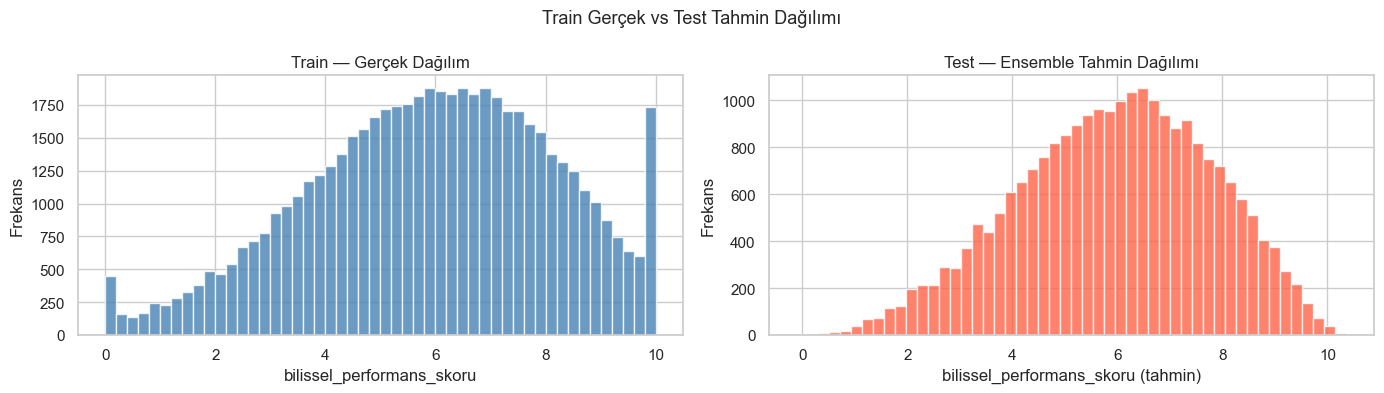

Train  — Ort: 5.913, Std: 2.232
Tahmin — Ort: 5.942, Std: 1.858


In [ ]:
# Train hedef vs test tahmin dagilimini karsilastir
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(y, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Train - Gercek Dagilim')
axes[0].set_xlabel('bilissel_performans_skoru')
axes[0].set_ylabel('Frekans')

axes[1].hist(test_cat, bins=50, color='tomato', edgecolor='white', alpha=0.8)
axes[1].set_title('Test - CatBoost Tahmin Dagilimi')
axes[1].set_xlabel('bilissel_performans_skoru (tahmin)')
axes[1].set_ylabel('Frekans')

plt.suptitle('Train Gercek vs Test Tahmin Dagilimi', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Train  - Ort: {y.mean():.3f}, Std: {y.std():.3f}')
print(f'Tahmin - Ort: {test_cat.mean():.3f}, Std: {test_cat.std():.3f}')

if test_cat.std() < y.std() * 0.6:
    print()
    print('UYARI: Tahmin std cok kucuk -- model ortalamanin etrafina sikismis olabilir.')

### 6.3 — Submission CSV Oluştur

In [ ]:
import os
os.makedirs('submissions', exist_ok=True)

submission = pd.DataFrame({
    'id'                        : test['id'].values.astype(int),
    'bilissel_performans_skoru' : np.clip(test_final, 0, 10),
})

submission_path = 'submissions/submission_v5_catboost_native.csv'
submission.to_csv(submission_path, index=False)
print(f'Kaydedildi: {submission_path}')
print(f'Satir: {len(submission)}')
print(submission.head().to_string(index=False))

Submission kaydedildi: submissions/submission_v4_stretched.csv
Satir sayisi: 24000

Ilk 5 satir:
 id  bilissel_performans_skoru
  1                   5.895598
  2                   6.316588
  3                   2.982056
  4                   7.098165
  5                   3.596997


### 6.4 — Format Doğrulama

In [ ]:
# Submission dosyasını yeniden oku ve kontrol et
sub_check = pd.read_csv(submission_path)

checks = {
    'Sütun sayısı doğru (2)' : len(sub_check.columns) == 2,
    'Sütun adları doğru'     : list(sub_check.columns) == ['id', 'bilissel_performans_skoru'],
    'Satır sayısı doğru (24000)': len(sub_check) == 24000,
    'id integer'             : sub_check['id'].dtype in ['int64', 'int32'],
    'Skor float'             : sub_check['bilissel_performans_skoru'].dtype == 'float64',
    'Eksik değer yok'        : sub_check.isnull().sum().sum() == 0,
    'Skor 0-10 arasında'     : (sub_check['bilissel_performans_skoru'].between(0, 10)).all(),
}

print('=== Submission Format Kontrolü ===')
all_ok = True
for check, result in checks.items():
    status = '✓' if result else '✗'
    print(f'  {status} {check}')
    if not result:
        all_ok = False

print()
if all_ok:
    print('→ Tüm kontroller geçti. Kaggle\'a yüklenmeye hazır!')
else:
    print('→ HATA: Bazı kontroller başarısız oldu. Yukarıdaki ✗ işaretlerini incele.')

=== Submission Format Kontrolü ===
  ✓ Sütun sayısı doğru (2)
  ✓ Sütun adları doğru
  ✓ Satır sayısı doğru (24000)
  ✓ id integer
  ✓ Skor float
  ✓ Eksik değer yok
  ✓ Skor 0-10 arasında

→ Tüm kontroller geçti. Kaggle'a yüklenmeye hazır!


**Bölüm 6 tamamlandı.**

- `submissions/submission_v1_ensemble.csv` oluşturuldu
- Format kontrolleri yapıldı (sütunlar, satır sayısı, tip, aralık)
- Kaggle'a yüklenmeye hazır

---

## Notebook Özeti

| Bölüm | İçerik | Durum |
|---|---|---|
| 0 | Kurulum, veri yükleme, temel inceleme | ✓ |
| 1 | EDA — korelasyon, dağılım, kategorik etkiler, aykırı değer | ✓ |
| 2 | Ön işleme — eksik değer, clip, encoding | ✓ |
| 3 | Feature engineering (8 yeni değişken) | ✓ |
| 4 | XGBoost + LightGBM + CatBoost (Optuna tuning + ensemble) | ✓ |
| 5 | Feature importance analizi | ✓ |
| 6 | Submission oluşturma ve format kontrolü | ✓ |

**Ensemble OOF RMSE: 1.21808** (CatBoost en iyi tek model: 1.21774)